# 00. 全体像 — 線形代数は「空間を見るための言語」

この教材は、線形代数を **空間・情報・変換・保存量を見るための言語** として学ぶための
Jupyter Notebook 教科書です。定義と定理の羅列ではなく、
「この概念は何を解決するのか」「幾何的には何が起きているのか」を、
図と Python 実験で先に掴んでから、数式に進みます。

```{admonition} 核心 — この教材のひとこと
:class: tip
**行列とは「空間を変形するルール」、線形代数とはそれを数の計算に翻訳する言語である。**
各章には、要点を一言で示す**「核心」コールアウト**、**スライダーで動かせる図**（静的 HTML でも動く）、
そして現場での使われ方を示す**「実社会では」コールアウト**を置いた。読むだけでなく動かして、なぜ役立つかまで掴んでほしい。
```

## 線形代数とは何か

一言でいえば、**「まっすぐな変換」だけを集中的に研究する数学** です。

- 「まっすぐな変換」= 直線を直線に移し、原点を動かさない変換(線形写像)
- その変換は **行列** という数の表で完全に記述できる
- だから「空間の変形」の問題が「数の計算」の問題に置き換わる

世の中の現象の多くは(少なくとも局所的には)線形で近似できます。
だから線形代数は、微積分と並んで、ほとんどすべての定量的な分野の共通言語になっています。

## なぜ学ぶのか — 分野別の動機

| 分野 | 線形代数が答える問い |
|---|---|
| 機械学習 | データ(行列)のどの方向に情報が詰まっているか(PCA・埋め込み・勾配) |
| 統計 | 最小二乗法はなぜ「正射影」なのか。共分散行列は何を表すか |
| 物理 | 固有値はなぜ「観測できる量」なのか(振動モード・量子力学) |
| 金融 | ポートフォリオのリスクはなぜ二次形式 $w^\top \Sigma w$ で書けるか |
| CG・ロボティクス | 回転・拡大・射影をどう合成して計算するか |
| 数値計算 | 連立方程式を「安全に」解くとはどういうことか(条件数) |

## この教材の全体マップ

7 つの章は、次の一本のストーリーでつながっています。

1. **ベクトル** — 量と方向をまとめて扱う(01章)
2. **行列** — 空間を変形するルール。行列式は面積の倍率(01章)
3. **連立方程式とランク** — 情報が何次元分残っているか(02章)
4. **線形写像と固有値** — 変換しても方向が変わらない特別な軸(03章)
5. **内積と正射影** — 「最も近い影」を落とす。解けない方程式を最小二乗で解く(04章)
6. **行列分解と SVD・PCA** — 任意の変換は「回転・伸縮・回転」に分解できる(05章)
7. **数値計算と最適化** — コンピュータで解くときに何が壊れるか(06章)
8. **応用** — グラフ・Markov 連鎖・金融・量子(07章)

キーワードを 1 行ずつでまとめると:

- ベクトル: 量と方向をまとめて扱うもの
- 行列: 空間を変形するルール
- ランク: 情報が何次元分残っているか
- 行列式: 面積・体積の倍率
- 固有ベクトル: 方向が変わらない特別な軸 / 固有値: その軸方向の伸び縮み
- 直交行列: 長さと角度を保存する変換
- 正射影: 一番近い影を落とす操作
- 最小二乗: 解けない方程式を、最も近く解く方法
- 条件数: 入力のズレがどれだけ増幅されるか
- SVD: 任意の変換を回転・伸縮・回転に分解する方法
- PCA: データのばらつきが大きい方向を探す方法

## 30秒プレビュー

この教材で繰り返し登場する 2 枚の絵を先に見ておきます。
1 枚目は「行列は空間を変形するルール」、2 枚目は「PCA はばらつきが大きい方向を探す」。
意味はこれから各章でじっくり説明するので、今は雰囲気だけで十分です。

In [1]:
# Shared setup used throughout the book.
import numpy as np
import matplotlib.pyplot as plt

from la_book import plotting
from la_book.datasets import make_correlated_cloud
from la_book.decompositions import pca_fit

np.set_printoptions(precision=3, suppress=True)

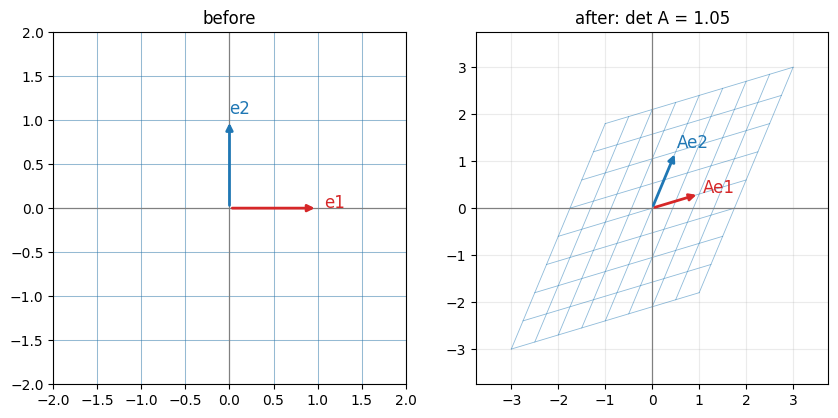

In [2]:
# A matrix deforms the whole plane: the grid before and after.
A = np.array([[1.0, 0.5],
              [0.3, 1.2]])
plotting.plot_grid_transform(A)
plt.show()

同じ「行列＝変形」を、スライダーで切り替えながら見るとこうなります（静的 HTML でも動く、各章で多用する形式）。

In [3]:
# Interactive teaser: switch transforms with a slider (works in the static HTML too).
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
theta = np.pi / 6
mats = [
    ("identity", np.eye(2)),
    ("scale", np.array([[1.5, 0.0], [0.0, 0.5]])),
    ("rotate 30", np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])),
    ("shear", np.array([[1.0, 1.0], [0.0, 1.0]])),
]
fig = plotting.plotly_grid_transform(
    [M for _, M in mats], [n for n, _ in mats],
    title="行列ごとにグリッドがどう歪むか（スライダーで切替）",
)
fig.show()

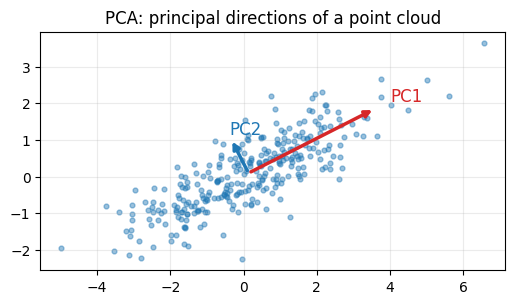

In [4]:
# PCA finds the directions where the data varies the most.
X = make_correlated_cloud(n=300, seed=0)
result = pca_fit(X)
plotting.plot_pca_axes(X, result)
plt.title("PCA: principal directions of a point cloud")
plt.show()

## この教材の読み方

各章(Notebook)は原則として次の 11 セクションで構成されています。

1. **Big Picture** — この章で何が分かるようになるか
2. **Problem** — 出発点となる具体的な問題
3. **Intuition** — 図とことばによる直感
4. **Visualization** — 概念を絵で確認する
5. **Definition** — ここで初めて定義・数式
6. **Computation** — Python での計算
7. **Invariant** — その操作で「何が保存されるか」
8. **Failure Mode** — 何が壊れると問題が起きるか
9. **Application** — どこで使われるか
10. **Exercises** — 演習
11. **Advanced Notes** — 証明・発展(初読では飛ばしてよい)

また、内容は 3 つの層に分かれています。

| 層 | 目安となるセクション | 内容 |
|---|---|---|
| **Basic** | 1〜5 | 初学者が最低限理解すべき内容 |
| **Applied** | 6〜10 | Python 実装・応用例 |
| **Advanced** | 11 | 証明・発展理論・実務上の注意 |

初読では Basic だけを 7 章まで通読し、2 周目に Applied のコードを手で動かす、
という読み方を推奨します。Advanced は必要になったときに戻ってくれば十分です。

さらに各章には、理解を助ける 3 つの仕掛けを共通で置いています。

- **核心** コールアウト（章頭）— その章のロジックの芯を一言で。
- **▶ 触って確かめる** — スライダーで動かせる Plotly 図。静的 HTML でも動くので、ビルドした教科書でもそのまま操作できます。
- **実社会では** コールアウト — その概念が現場のどこで効くか。

「読む」だけでなく「動かす」「なぜ役立つかを掴む」ことを重視した構成です。

## Python 環境の準備

この教材は `la_book` という小さな補助パッケージ(描画・分解・データ生成)を使います。
セットアップはリポジトリの `README.md` の手順どおりです。

```bash
# workspace ルートで(uv 利用)
make install
uv run jupyter lab analytics/linear_algebra/notebooks/

# または単体で
pip install -r requirements.txt && pip install -e .
```

下のセルが動けば準備完了です。

In [5]:
# Environment check: versions of the main libraries.
import matplotlib
import pandas
import plotly
import scipy
import sklearn
import sympy

import la_book

for name, mod in [
    ("numpy", np), ("scipy", scipy), ("sympy", sympy),
    ("matplotlib", matplotlib), ("plotly", plotly),
    ("pandas", pandas), ("scikit-learn", sklearn), ("la_book", la_book),
]:
    print(f"{name:>13}: {mod.__version__}")

        numpy: 2.4.6
        scipy: 1.17.1
        sympy: 1.14.0
   matplotlib: 3.10.9
       plotly: 6.7.0
       pandas: 3.0.3
 scikit-learn: 1.9.0
      la_book: 0.1.0


## 表記について

- 本文は日本語、コードとコメントは英語です。
- ベクトルは小文字($v, w$)、行列は大文字($A, B$)、スカラーはギリシャ文字や小文字を使います。
- $\mathbb{R}^n$ は実数を $n$ 個並べたベクトル全体の集合を表します。
- 数式の中には日本語を入れず、説明は数式の外の本文で行います。

それでは [01. ベクトルと行列の幾何](01_vectors_matrices_geometry.ipynb) から始めましょう。